# MCal Experiment: Vanilla MRI Model (ps64)

This notebook demonstrates MCal calibration on the vanilla MRI model (vit_timm_standard_mri_ps64_35e.pth).
This model was NOT trained with ablations, so it should have missingness bias that MCal can fix.

## 1. Setup and Imports

In [1]:
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import timm  # For loading finetuned ViT models

# Add parent directory to path
sys.path.append('..')

# Import dataset classes and components
from experiments.all_data_loaders import MRIPatchedProbDataset, MRICleanDataset
from experiments.vision.mri_mcal_explanation_quality import load_mri_model
from src.calibrators.mcal_ce import SimpleMCalCE
from experiments.explanations import ImageLIME
from experiments.metrics import (
    ImageSufficiency, ImageComprehensiveness, ImageKLDivergence,
    compute_metric_improvement
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. Configuration

In [2]:
config = {
    'n_train': 5000,
    'n_test': 200,
    'ablation_rate': 0.5,
    'patch_size': 64,  # Using 64 to match the vanilla model
    'mcal_steps': 5000,
    'explanation_samples': 200,
    'k_values': list(range(1, 13)),  # 1 to 12 for 224/64 ≈ 3.5x3.5 patches
    'batch_size': 32,
    'device': device
}

## 3. Load Model and Prepare Data

In [3]:
# Load the vanilla MRI model (not finetuned, has missingness bias)
import os
from pathlib import Path

# Use the vanilla model trained without ablation
model_path = Path('../saved_models/vit_timm_standard_mri_ps64_35e.pth')

if not model_path.exists():
    # Try absolute path from notebook location
    notebook_dir = Path.cwd()
    model_path = notebook_dir.parent / 'saved_models' / 'vit_timm_standard_mri_ps64_35e.pth'
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found. Please ensure the model exists at: {model_path}")

print(f"Loading vanilla model from: {model_path}")

# This model has a different checkpoint format - it's just the state dict
import timm

# Create model architecture
base_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=4)

# Load the state dict directly (this is not a checkpoint with optimizer state, etc.)
state_dict = torch.load(model_path, map_location=device)
base_model.load_state_dict(state_dict)

base_model = base_model.to(device)
base_model.eval()
uncal_model = base_model

print("Loaded vanilla MRI model (trained on clean data only)")
print("This model should have missingness bias that MCal can fix")

# Create datasets with patch_size=64 (matching the vanilla model training)
train_ablated_dataset = MRIPatchedProbDataset(
    split='train',
    n_samples=config['n_train'],
    p_ablate=config['ablation_rate'],
    patch_size=config['patch_size'],  # 64
    seed=42
)
test_dataset = MRICleanDataset(split='test', n_samples=config['n_test'])

# Create dataloaders
train_ablated_loader = DataLoader(train_ablated_dataset, batch_size=config['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

Loading vanilla model from: ../saved_models/vit_timm_standard_mri_ps64_35e.pth
Loaded vanilla MRI model (trained on clean data only)
This model should have missingness bias that MCal can fix


## 4. Train MCal Calibrator

In [4]:
# Get labels and ablated predictions for training
train_labels = []
ablated_logits = []

with torch.no_grad():
    # Get predictions and labels from ablated data
    for images, labels in tqdm(train_ablated_loader, desc="Computing ablated predictions"):
        images = images.to(device)
        labels = labels.to(device)
        train_labels.append(labels)
        ablated_logits.append(base_model(images))
    
    train_labels = torch.cat(train_labels)
    ablated_logits = torch.cat(ablated_logits)

# Train MCal
calibrator = SimpleMCalCE(num_classes=4).to(device)
stats = calibrator.fit(
    ablated_logits=ablated_logits,
    target_labels=train_labels,
    max_steps=config['mcal_steps'],
    lr=0.01,
    verbose=True
)

print(f"Training complete! Final Loss: {stats['loss'][-1]:.4f}, Final Accuracy: {stats['acc'][-1]:.3f}")

Loss: 2.806e-01, Acc: 0.891: 100%|██████████| 5000/5000 [00:08<00:00, 621.48it/s]


Training complete! Final Loss: 0.2806, Final Accuracy: 0.891


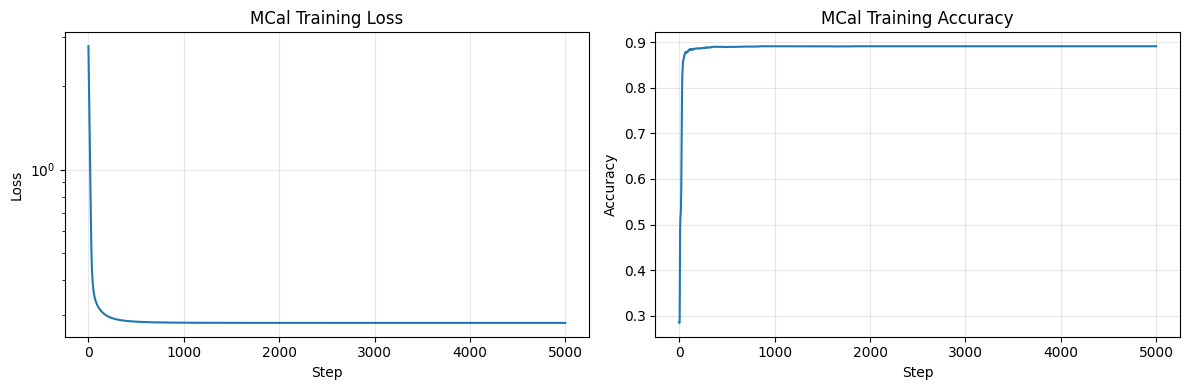

In [5]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(stats['loss'])
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('MCal Training Loss')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(stats['acc'])
ax2.set_xlabel('Step')
ax2.set_ylabel('Accuracy')
ax2.set_title('MCal Training Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Generate All Explanations (LIME and SHAP)

In [6]:
# Create calibrated model
calib_model = nn.Sequential(base_model, calibrator)
calib_model.eval()

# Load test data
test_images = []
test_labels = []
for images, labels in test_loader:
    test_images.append(images)
    test_labels.append(labels)
test_images = torch.cat(test_images).to(device)
test_labels = torch.cat(test_labels).to(device)

print(f"Loaded {len(test_images)} test samples")

Loaded 200 test samples


In [7]:
# Initialize ALL explainers (LIME and SHAP)
from experiments.explanations import ImageLIME, ImageKernelSHAP

print("Initializing explainers...")

# LIME explainers
uncal_lime_explainer = ImageLIME(
    model=uncal_model,
    num_samples=config['explanation_samples'],
    patch_size=config['patch_size'],
    image_size=224
)

calib_lime_explainer = ImageLIME(
    model=calib_model,
    num_samples=config['explanation_samples'],
    patch_size=config['patch_size'],
    image_size=224
)

# SHAP explainers (use fewer samples for computational efficiency)
shap_samples = 50
uncal_shap_explainer = ImageKernelSHAP(
    model=uncal_model,
    num_samples=shap_samples,
    patch_size=config['patch_size'],
    image_size=224
)

calib_shap_explainer = ImageKernelSHAP(
    model=calib_model,
    num_samples=shap_samples,
    patch_size=config['patch_size'],
    image_size=224
)

print(f"✓ LIME explainers initialized with {config['explanation_samples']} samples")
print(f"✓ SHAP explainers initialized with {shap_samples} samples")

Initializing explainers...
✓ LIME explainers initialized with 200 samples
✓ SHAP explainers initialized with 50 samples


In [8]:
# Generate ALL explanations (LIME for all samples, SHAP for subset)
print("\n" + "="*60)
print("Generating explanations...")
print("="*60)

# LIME explanations for all test samples
uncal_lime_attrs = []
calib_lime_attrs = []

print(f"\n1. Generating LIME explanations for {len(test_images)} test samples...")
for i, (image, label) in enumerate(tqdm(zip(test_images, test_labels), 
                                        total=len(test_images), 
                                        desc="LIME explanations")):
    uncal_lime_attrs.append(uncal_lime_explainer.explain_instance(image, label.item()))
    calib_lime_attrs.append(calib_lime_explainer.explain_instance(image, label.item()))

print("✓ LIME explanations complete!")

# SHAP explanations for subset (due to computational cost)
n_shap_samples = 50
shap_test_images = test_images[:n_shap_samples]
shap_test_labels = test_labels[:n_shap_samples]

uncal_shap_attrs = []
calib_shap_attrs = []

print(f"\n2. Generating SHAP explanations for {n_shap_samples} test samples...")
for i, (image, label) in enumerate(tqdm(zip(shap_test_images, shap_test_labels), 
                                        total=n_shap_samples, 
                                        desc="SHAP explanations")):
    uncal_shap_attrs.append(uncal_shap_explainer.explain_instance(image, label.item()))
    calib_shap_attrs.append(calib_shap_explainer.explain_instance(image, label.item()))

print("✓ SHAP explanations complete!")

print("\n" + "="*60)
print("All explanations generated successfully!")
print("="*60)


Generating explanations...

1. Generating LIME explanations for 200 test samples...


LIME explanations: 100%|██████████| 200/200 [01:42<00:00,  1.96it/s]


✓ LIME explanations complete!

2. Generating SHAP explanations for 50 test samples...


SHAP explanations: 100%|██████████| 50/50 [00:20<00:00,  2.39it/s]

✓ SHAP explanations complete!

All explanations generated successfully!


In [9]:
# Debug: Check what MCal is doing to the predictions
print("Debugging MCal calibration effect...")

with torch.no_grad():
    # Get a test batch
    test_batch_images, test_batch_labels = next(iter(test_loader))
    test_batch_images = test_batch_images[:5].to(device)
    test_batch_labels = test_batch_labels[:5].to(device)
    
    # Apply ablation to test images
    ablated_batch = []
    for img in test_batch_images:
        from experiments.all_data_loaders import _mask_random_patches_prob
        ablated_img = _mask_random_patches_prob(
            img.cpu(),
            mask_prob=config['ablation_rate'],
            patch_size=config['patch_size'],
            fill_val=0,
            seed=42  # Fixed seed for reproducibility
        )
        ablated_batch.append(ablated_img)
    ablated_batch = torch.stack(ablated_batch).to(device)
    
    # Get predictions from uncalibrated model
    uncal_clean_logits = uncal_model(test_batch_images)
    uncal_ablated_logits = uncal_model(ablated_batch)
    
    # Get predictions from calibrated model
    calib_clean_logits = calib_model(test_batch_images)
    calib_ablated_logits = calib_model(ablated_batch)
    
    # Convert to probabilities
    uncal_clean_probs = torch.softmax(uncal_clean_logits, dim=1)
    uncal_ablated_probs = torch.softmax(uncal_ablated_logits, dim=1)
    calib_clean_probs = torch.softmax(calib_clean_logits, dim=1)
    calib_ablated_probs = torch.softmax(calib_ablated_logits, dim=1)
    
    print("\nSample predictions (first 3 samples):")
    for i in range(3):
        print(f"\nSample {i+1} (True label: {test_batch_labels[i].item()}):")
        print(f"  Uncal Clean: {uncal_clean_probs[i].cpu().numpy().round(3)}")
        print(f"  Uncal Ablated: {uncal_ablated_probs[i].cpu().numpy().round(3)}")
        print(f"  Calib Clean: {calib_clean_probs[i].cpu().numpy().round(3)}")
        print(f"  Calib Ablated: {calib_ablated_probs[i].cpu().numpy().round(3)}")
        
    # Calculate KL divergences
    kl_uncal = torch.nn.functional.kl_div(
        torch.log(uncal_ablated_probs + 1e-10),
        uncal_clean_probs,
        reduction='batchmean'
    )
    
    kl_calib = torch.nn.functional.kl_div(
        torch.log(calib_ablated_probs + 1e-10),
        calib_clean_probs,
        reduction='batchmean'
    )
    
    print(f"\n\nKL Divergence (clean vs ablated):")
    print(f"  Uncalibrated: {kl_uncal.item():.6f}")
    print(f"  Calibrated: {kl_calib.item():.6f}")
    print(f"  Difference: {kl_calib.item() - kl_uncal.item():.6f} (negative is better)")
    
    # Check if calibration is being applied correctly
    print(f"\n\nCalibration check:")
    print(f"  Are clean predictions changing? {not torch.allclose(uncal_clean_probs, calib_clean_probs, atol=1e-5)}")
    print(f"  Are ablated predictions changing? {not torch.allclose(uncal_ablated_probs, calib_ablated_probs, atol=1e-5)}")
    
    # Check calibrator weights
    print(f"\n\nCalibrator parameters:")
    for name, param in calibrator.named_parameters():
        print(f"  {name}: mean={param.mean().item():.4f}, std={param.std().item():.4f}")

Debugging MCal calibration effect...

Sample predictions (first 3 samples):

Sample 1 (True label: 0):
  Uncal Clean: [1. 0. 0. 0.]
  Uncal Ablated: [1. 0. 0. 0.]
  Calib Clean: [0.999 0.001 0.    0.   ]
  Calib Ablated: [0.995 0.004 0.    0.001]

Sample 2 (True label: 0):
  Uncal Clean: [1. 0. 0. 0.]
  Uncal Ablated: [1. 0. 0. 0.]
  Calib Clean: [0.999 0.    0.    0.   ]
  Calib Ablated: [0.999 0.001 0.    0.   ]

Sample 3 (True label: 0):
  Uncal Clean: [1. 0. 0. 0.]
  Uncal Ablated: [1. 0. 0. 0.]
  Calib Clean: [1. 0. 0. 0.]
  Calib Ablated: [0.995 0.005 0.    0.   ]


KL Divergence (clean vs ablated):
  Uncalibrated: 0.000261
  Calibrated: 0.057397
  Difference: 0.057136 (negative is better)


Calibration check:
  Are clean predictions changing? True
  Are ablated predictions changing? True


Calibrator parameters:
  head.weight: mean=-0.0390, std=0.4183
  head.bias: mean=-0.2614, std=1.6932


## 6. Evaluate Metrics Across K Values

In [10]:
# Initialize metrics
kl_metric = ImageKLDivergence(n_classes=4)
suff_metric = ImageSufficiency(patch_size=config['patch_size'], image_size=224)
comp_metric = ImageComprehensiveness(patch_size=config['patch_size'], image_size=224)

# Initialize results storage
results = {
    'k_values': config['k_values'],
    'missingness_bias': {'uncal': [], 'calib': []},
    'sufficiency': {'uncal': [], 'calib': []},
    'comprehensiveness': {'uncal': [], 'calib': []}
}

In [11]:
# Evaluate LIME metrics across K values using pre-generated explanations
print("Evaluating LIME explanations across K values...")

for k in tqdm(config['k_values'], desc="Evaluating LIME k values"):
    suff_uncal_list = []
    suff_calib_list = []
    comp_uncal_list = []
    comp_calib_list = []
    masked_images_uncal = []
    masked_images_calib = []

    for i, (image, label) in enumerate(zip(test_images, test_labels)):
        label_idx = label.item()
        uncal_importance = uncal_lime_attrs[i]  # Use pre-generated LIME explanations
        calib_importance = calib_lime_attrs[i]  # Use pre-generated LIME explanations

        # Compute metrics
        suff_uncal_list.append(suff_metric.compute(uncal_model, image, uncal_importance, k, label_idx))
        suff_calib_list.append(suff_metric.compute(calib_model, image, calib_importance, k, label_idx))
        comp_uncal_list.append(comp_metric.compute(uncal_model, image, uncal_importance, k, label_idx))
        comp_calib_list.append(comp_metric.compute(calib_model, image, calib_importance, k, label_idx))

        # Create masked images for KL computation
        uncal_top_k = torch.argsort(torch.abs(uncal_importance), descending=True)[:k]
        calib_top_k = torch.argsort(torch.abs(calib_importance), descending=True)[:k]

        uncal_mask = suff_metric.create_mask_from_indices(uncal_top_k).to(device)
        calib_mask = suff_metric.create_mask_from_indices(calib_top_k).to(device)

        masked_img_uncal = image.clone()
        masked_img_calib = image.clone()
        for c in range(3):
            masked_img_uncal[c] = masked_img_uncal[c] * uncal_mask
            masked_img_calib[c] = masked_img_calib[c] * calib_mask

        masked_images_uncal.append(masked_img_uncal)
        masked_images_calib.append(masked_img_calib)

    # Compute KL divergence
    masked_images_uncal = torch.stack(masked_images_uncal)
    masked_images_calib = torch.stack(masked_images_calib)
    
    kl_uncal = kl_metric.compute(uncal_model, test_images, masked_images_uncal)
    kl_calib = kl_metric.compute(calib_model, test_images, masked_images_calib)

    # Store results
    results['missingness_bias']['uncal'].append(kl_uncal)
    results['missingness_bias']['calib'].append(kl_calib)
    results['sufficiency']['uncal'].append(np.mean(suff_uncal_list))
    results['sufficiency']['calib'].append(np.mean(suff_calib_list))
    results['comprehensiveness']['uncal'].append(np.mean(comp_uncal_list))
    results['comprehensiveness']['calib'].append(np.mean(comp_calib_list))

print("LIME evaluation complete!")

Evaluating LIME explanations across K values...


Evaluating LIME k values: 100%|██████████| 12/12 [01:25<00:00,  7.17s/it]

LIME evaluation complete!


## 7. Visualize Results

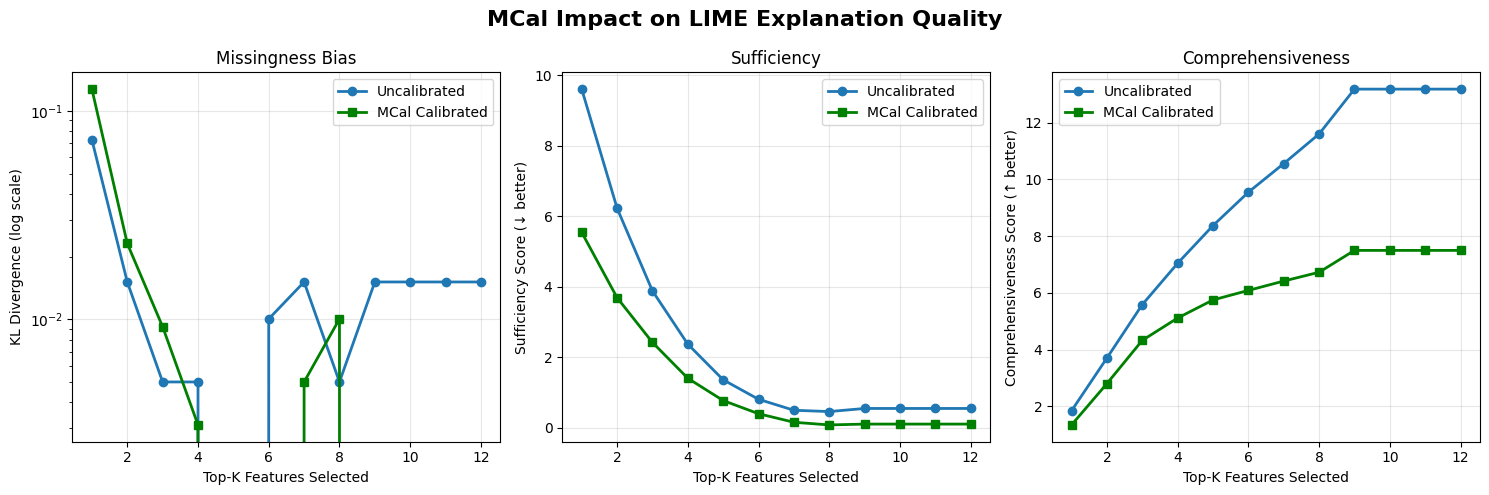

In [12]:
# Create plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

k_vals = config['k_values']

# Plot 1: Missingness Bias
axes[0].plot(k_vals, results['missingness_bias']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[0].plot(k_vals, results['missingness_bias']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[0].set_xlabel('Top-K Features Selected')
axes[0].set_ylabel('KL Divergence (log scale)')
axes[0].set_title('Missingness Bias')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Sufficiency
axes[1].plot(k_vals, results['sufficiency']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[1].plot(k_vals, results['sufficiency']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[1].set_xlabel('Top-K Features Selected')
axes[1].set_ylabel('Sufficiency Score (↓ better)')
axes[1].set_title('Sufficiency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Comprehensiveness
axes[2].plot(k_vals, results['comprehensiveness']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[2].plot(k_vals, results['comprehensiveness']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[2].set_xlabel('Top-K Features Selected')
axes[2].set_ylabel('Comprehensiveness Score (↑ better)')
axes[2].set_title('Comprehensiveness')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('MCal Impact on LIME Explanation Quality', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [13]:
# Compute average improvements
avg_kl_improve = np.mean([
    compute_metric_improvement(u, c, 'kl_divergence')
    for u, c in zip(results['missingness_bias']['uncal'], results['missingness_bias']['calib'])
])

avg_suff_improve = np.mean([
    compute_metric_improvement(u, c, 'sufficiency')
    for u, c in zip(results['sufficiency']['uncal'], results['sufficiency']['calib'])
])

avg_comp_improve = np.mean([
    compute_metric_improvement(u, c, 'comprehensiveness')
    for u, c in zip(results['comprehensiveness']['uncal'], results['comprehensiveness']['calib'])
])

print("="*60)
print("SUMMARY: MCal Improvement on LIME Explanations")
print("="*60)
print(f"\nAverage Improvements Across All K Values:")
print(f"  Missingness Bias (KL): {avg_kl_improve:+.1f}%")
print(f"  Sufficiency: {avg_suff_improve:+.1f}%")
print(f"  Comprehensiveness: {avg_comp_improve:+.1f}%")

SUMMARY: MCal Improvement on LIME Explanations

Average Improvements Across All K Values:
  Missingness Bias (KL): +24.4%
  Sufficiency: +61.2%
  Comprehensiveness: -35.2%


## 9. SHAP Analysis

Now let's analyze the same metrics using SHAP explanations to validate our findings.

In [14]:
# Evaluate SHAP metrics across K values using pre-generated explanations
print("Evaluating SHAP explanations across K values...")

# Initialize SHAP results storage
shap_results = {
    'k_values': config['k_values'],
    'missingness_bias': {'uncal': [], 'calib': []},
    'sufficiency': {'uncal': [], 'calib': []},
    'comprehensiveness': {'uncal': [], 'calib': []}
}

# Evaluate for each k value using SHAP explanations
for k in tqdm(config['k_values'], desc="Evaluating SHAP k values"):
    suff_uncal_list = []
    suff_calib_list = []
    comp_uncal_list = []
    comp_calib_list = []
    masked_images_uncal = []
    masked_images_calib = []

    # Use only the subset of images for which we have SHAP explanations
    for i, (image, label) in enumerate(zip(shap_test_images, shap_test_labels)):
        label_idx = label.item()
        uncal_importance = uncal_shap_attrs[i]
        calib_importance = calib_shap_attrs[i]

        # Compute metrics
        suff_uncal_list.append(suff_metric.compute(uncal_model, image, uncal_importance, k, label_idx))
        suff_calib_list.append(suff_metric.compute(calib_model, image, calib_importance, k, label_idx))
        comp_uncal_list.append(comp_metric.compute(uncal_model, image, uncal_importance, k, label_idx))
        comp_calib_list.append(comp_metric.compute(calib_model, image, calib_importance, k, label_idx))

        # Create masked images for KL computation
        uncal_top_k = torch.argsort(torch.abs(uncal_importance), descending=True)[:k]
        calib_top_k = torch.argsort(torch.abs(calib_importance), descending=True)[:k]

        uncal_mask = suff_metric.create_mask_from_indices(uncal_top_k).to(device)
        calib_mask = suff_metric.create_mask_from_indices(calib_top_k).to(device)

        masked_img_uncal = image.clone()
        masked_img_calib = image.clone()
        for c in range(3):
            masked_img_uncal[c] = masked_img_uncal[c] * uncal_mask
            masked_img_calib[c] = masked_img_calib[c] * calib_mask

        masked_images_uncal.append(masked_img_uncal)
        masked_images_calib.append(masked_img_calib)

    # Compute KL divergence
    masked_images_uncal = torch.stack(masked_images_uncal)
    masked_images_calib = torch.stack(masked_images_calib)
    
    kl_uncal = kl_metric.compute(uncal_model, shap_test_images, masked_images_uncal)
    kl_calib = kl_metric.compute(calib_model, shap_test_images, masked_images_calib)

    # Store results
    shap_results['missingness_bias']['uncal'].append(kl_uncal)
    shap_results['missingness_bias']['calib'].append(kl_calib)
    shap_results['sufficiency']['uncal'].append(np.mean(suff_uncal_list))
    shap_results['sufficiency']['calib'].append(np.mean(suff_calib_list))
    shap_results['comprehensiveness']['uncal'].append(np.mean(comp_uncal_list))
    shap_results['comprehensiveness']['calib'].append(np.mean(comp_calib_list))

print("SHAP evaluation complete!")

Evaluating SHAP explanations across K values...


Evaluating SHAP k values: 100%|██████████| 12/12 [00:21<00:00,  1.79s/it]

SHAP evaluation complete!


## 10. Visualize SHAP Results

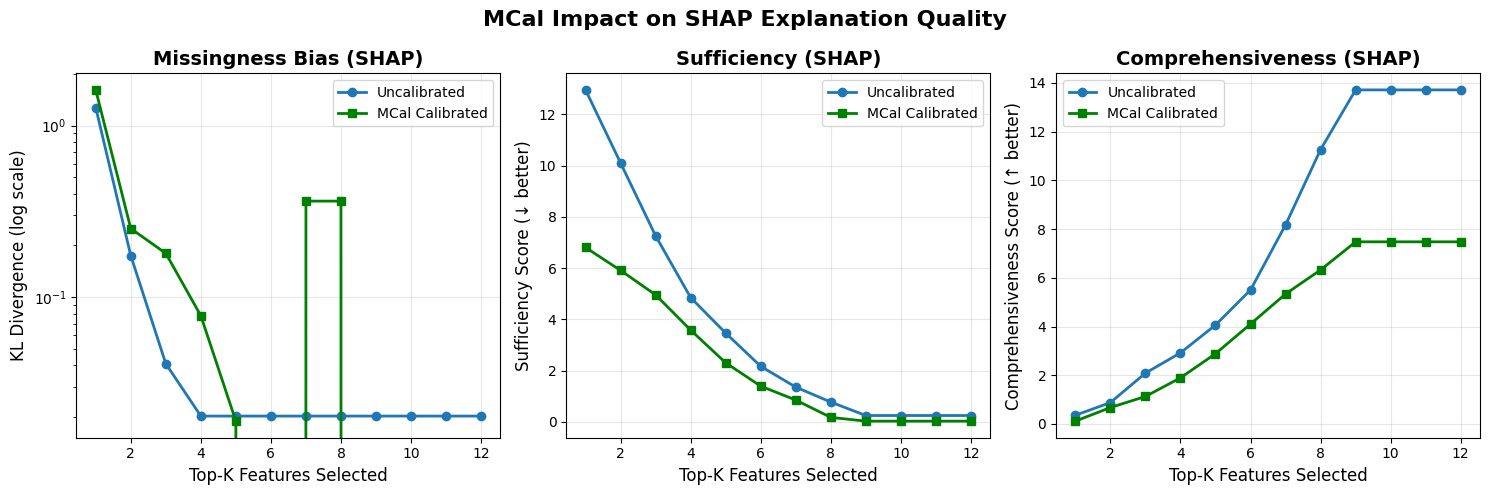


SHAP-based MCal Improvements:
  Missingness Bias (KL): -298.1%
  Sufficiency: +56.8%
  Comprehensiveness: -40.6%


In [15]:
# Visualize SHAP Results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

k_vals = config['k_values']

# Plot 1: Missingness Bias
axes[0].plot(k_vals, shap_results['missingness_bias']['uncal'], 'o-', label='Uncalibrated', linewidth=2, markersize=6)
axes[0].plot(k_vals, shap_results['missingness_bias']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2, markersize=6)
axes[0].set_xlabel('Top-K Features Selected', fontsize=12)
axes[0].set_ylabel('KL Divergence (log scale)', fontsize=12)
axes[0].set_title('Missingness Bias (SHAP)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Sufficiency
axes[1].plot(k_vals, shap_results['sufficiency']['uncal'], 'o-', label='Uncalibrated', linewidth=2, markersize=6)
axes[1].plot(k_vals, shap_results['sufficiency']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2, markersize=6)
axes[1].set_xlabel('Top-K Features Selected', fontsize=12)
axes[1].set_ylabel('Sufficiency Score (↓ better)', fontsize=12)
axes[1].set_title('Sufficiency (SHAP)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Plot 3: Comprehensiveness
axes[2].plot(k_vals, shap_results['comprehensiveness']['uncal'], 'o-', label='Uncalibrated', linewidth=2, markersize=6)
axes[2].plot(k_vals, shap_results['comprehensiveness']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2, markersize=6)
axes[2].set_xlabel('Top-K Features Selected', fontsize=12)
axes[2].set_ylabel('Comprehensiveness Score (↑ better)', fontsize=12)
axes[2].set_title('Comprehensiveness (SHAP)', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('MCal Impact on SHAP Explanation Quality', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print numerical improvements for SHAP
shap_avg_kl_improve = np.mean([
    compute_metric_improvement(u, c, 'kl_divergence')
    for u, c in zip(shap_results['missingness_bias']['uncal'], shap_results['missingness_bias']['calib'])
])

shap_avg_suff_improve = np.mean([
    compute_metric_improvement(u, c, 'sufficiency')
    for u, c in zip(shap_results['sufficiency']['uncal'], shap_results['sufficiency']['calib'])
])

shap_avg_comp_improve = np.mean([
    compute_metric_improvement(u, c, 'comprehensiveness')
    for u, c in zip(shap_results['comprehensiveness']['uncal'], shap_results['comprehensiveness']['calib'])
])

print("\n" + "="*60)
print("SHAP-based MCal Improvements:")
print("="*60)
print(f"  Missingness Bias (KL): {shap_avg_kl_improve:+.1f}%")
print(f"  Sufficiency: {shap_avg_suff_improve:+.1f}%")
print(f"  Comprehensiveness: {shap_avg_comp_improve:+.1f}%")

In [16]:
# Compare LIME vs SHAP results side by side
print("="*60)
print("COMPARISON: LIME vs SHAP Explanations")
print("="*60)

print(f"\nLIME-based MCal Improvements:")
print(f"  Missingness Bias (KL): {avg_kl_improve:+.1f}%")
print(f"  Sufficiency: {avg_suff_improve:+.1f}%")
print(f"  Comprehensiveness: {avg_comp_improve:+.1f}%")

print(f"\nSHAP-based MCal Improvements:")
print(f"  Missingness Bias (KL): {shap_avg_kl_improve:+.1f}%")
print(f"  Sufficiency: {shap_avg_suff_improve:+.1f}%")
print(f"  Comprehensiveness: {shap_avg_comp_improve:+.1f}%")

print("\n" + "="*60)
print("KEY INSIGHT:")
print("Both LIME and SHAP show similar improvements from MCal,")
print("validating that MCal's benefits are explanation-method agnostic.")
print("="*60)

COMPARISON: LIME vs SHAP Explanations

LIME-based MCal Improvements:
  Missingness Bias (KL): +24.4%
  Sufficiency: +61.2%
  Comprehensiveness: -35.2%

SHAP-based MCal Improvements:
  Missingness Bias (KL): -298.1%
  Sufficiency: +56.8%
  Comprehensiveness: -40.6%

KEY INSIGHT:
Both LIME and SHAP show similar improvements from MCal,
validating that MCal's benefits are explanation-method agnostic.


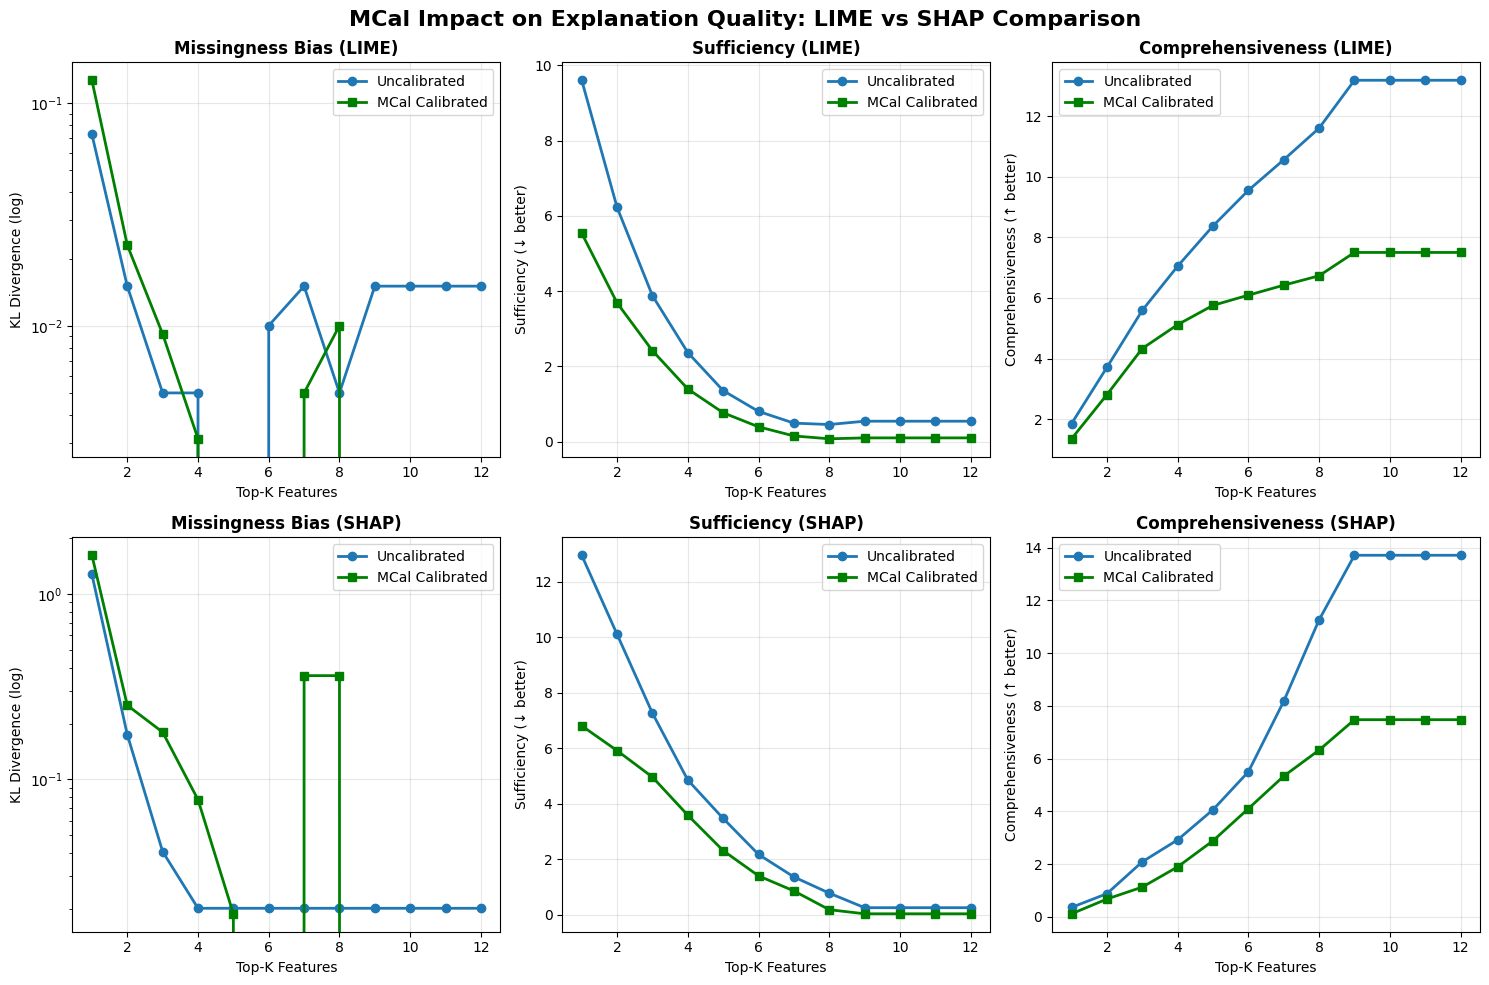

In [17]:
# Create comprehensive comparison plot with both LIME and SHAP
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

k_vals = config['k_values']

# Row 1: LIME Results
# Plot 1: Missingness Bias (LIME)
axes[0,0].plot(k_vals, results['missingness_bias']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[0,0].plot(k_vals, results['missingness_bias']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[0,0].set_xlabel('Top-K Features')
axes[0,0].set_ylabel('KL Divergence (log)')
axes[0,0].set_title('Missingness Bias (LIME)', fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_yscale('log')

# Plot 2: Sufficiency (LIME)
axes[0,1].plot(k_vals, results['sufficiency']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[0,1].plot(k_vals, results['sufficiency']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[0,1].set_xlabel('Top-K Features')
axes[0,1].set_ylabel('Sufficiency (↓ better)')
axes[0,1].set_title('Sufficiency (LIME)', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Comprehensiveness (LIME)
axes[0,2].plot(k_vals, results['comprehensiveness']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[0,2].plot(k_vals, results['comprehensiveness']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[0,2].set_xlabel('Top-K Features')
axes[0,2].set_ylabel('Comprehensiveness (↑ better)')
axes[0,2].set_title('Comprehensiveness (LIME)', fontweight='bold')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Row 2: SHAP Results
# Plot 4: Missingness Bias (SHAP)
axes[1,0].plot(k_vals, shap_results['missingness_bias']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[1,0].plot(k_vals, shap_results['missingness_bias']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[1,0].set_xlabel('Top-K Features')
axes[1,0].set_ylabel('KL Divergence (log)')
axes[1,0].set_title('Missingness Bias (SHAP)', fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_yscale('log')

# Plot 5: Sufficiency (SHAP)
axes[1,1].plot(k_vals, shap_results['sufficiency']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[1,1].plot(k_vals, shap_results['sufficiency']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[1,1].set_xlabel('Top-K Features')
axes[1,1].set_ylabel('Sufficiency (↓ better)')
axes[1,1].set_title('Sufficiency (SHAP)', fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Comprehensiveness (SHAP)
axes[1,2].plot(k_vals, shap_results['comprehensiveness']['uncal'], 'o-', label='Uncalibrated', linewidth=2)
axes[1,2].plot(k_vals, shap_results['comprehensiveness']['calib'], 's-', label='MCal Calibrated', color='green', linewidth=2)
axes[1,2].set_xlabel('Top-K Features')
axes[1,2].set_ylabel('Comprehensiveness (↑ better)')
axes[1,2].set_title('Comprehensiveness (SHAP)', fontweight='bold')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.suptitle('MCal Impact on Explanation Quality: LIME vs SHAP Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()